# Customer Segmentation on Online Retail II

Which customers are worth spending marketing money on, and which aren't?

The answer here is stark: **19% of customers produce 72% of revenue**. That single fact is
what a segmentation is for — it turns one undifferentiated customer file into four
audiences with obvious and different actions.

**Data.** [Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) —
1.07M invoice lines from a UK online retailer, Dec 2009 to Dec 2011. Every customer
feature below is built from those raw lines; nothing is pre-aggregated.

**Method.** RFM plus a few behavioural features, log-transformed, K-Means. The two choices
that actually matter are the log transform (Section 3) and how K was picked (Section 4) —
both are places where the obvious answer is the wrong one.

**Output.** Six CSVs in `dashboard/data/` that feed the Power BI report, written in
Section 8.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

RAW_FILE = Path("data/raw/online_retail_II.xlsx")
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
BI_DIR = Path("dashboard/data"); BI_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
CLUSTER_FEATURES = ["Recency", "Frequency", "Monetary"]

# Stock codes that are postage, fees or adjustments rather than products.
# Left in, they inflate Monetary for customers who simply paid more shipping.
NON_PRODUCT_CODES = {
    "POST", "DOT", "M", "S", "AMAZONFEE", "BANK CHARGES", "C2", "D",
    "CRUK", "ADJUST", "ADJUST2", "TEST001", "TEST002", "PADS", "B",
}

# A customer whose silhouette is below this sits nearer a rival cluster's
# territory than the comfortable middle of its own.
BORDERLINE_SILHOUETTE = 0.25

# Okabe-Ito steps, validated for colourblind separation (worst adjacent pair
# dE 11.0 deuteranopia). One fixed colour per segment across every figure.
SEGMENT_COLORS = {
    "Champions": "#0072B2",
    "At Risk": "#D55E00",
    "New Customers": "#009E73",
    "Hibernating": "#E69F00",
}
INK, MUTED, GRID = "#1a1a1a", "#6b6b6b", "#e0e0e0"

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "axes.edgecolor": MUTED, "axes.linewidth": 0.8,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.6,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "legend.frameon": False, "figure.facecolor": "white",
})

def finish(ax, title, xlabel, ylabel):
    ax.set_title(title, loc="left", pad=10)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)

## 1. Load and clean

The workbook has two sheets, one per year. Four things get dropped, and each is counted
rather than removed quietly — the numbers are the honest record of what the analysis is
built on.

Cancelled invoices (the `C` prefix) are credit notes, not purchases. Rows without a
`CustomerID` are anonymous till sales, which can't be attributed to anyone. Non-positive
quantity or price are returns and adjustment postings. And postage, fees and bad-debt
codes aren't products.

In [2]:
sheets = pd.read_excel(RAW_FILE, sheet_name=None,
                       dtype={"Invoice": str, "StockCode": str})
raw = pd.concat(sheets.values(), ignore_index=True)
raw.columns = [c.strip().replace(" ", "") for c in raw.columns]
print(f"raw invoice lines: {len(raw):,}")
raw.head(3)

raw invoice lines: 1,067,371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [3]:
n0 = len(raw)
tx = raw[~raw["Invoice"].str.startswith("C", na=False)]
n1 = len(tx)
tx = tx[(tx["Quantity"] > 0) & (tx["Price"] > 0)]
n2 = len(tx)
tx = tx.dropna(subset=["CustomerID"])
n3 = len(tx)
tx = tx[~tx["StockCode"].str.upper().isin(NON_PRODUCT_CODES)].copy()
n4 = len(tx)

tx["CustomerID"] = tx["CustomerID"].astype(int)
tx["Revenue"] = tx["Quantity"] * tx["Price"]
tx["InvoiceDate"] = pd.to_datetime(tx["InvoiceDate"])
tx = tx.reset_index(drop=True)

pd.DataFrame([
    {"step": "raw invoice lines", "rows": n0, "dropped": 0},
    {"step": "cancelled invoices", "rows": n1, "dropped": n0 - n1},
    {"step": "non-positive qty/price", "rows": n2, "dropped": n1 - n2},
    {"step": "missing CustomerID", "rows": n3, "dropped": n2 - n3},
    {"step": "non-product stock codes", "rows": n4, "dropped": n3 - n4},
]).assign(kept=lambda d: (d["rows"] / n0 * 100).round(1))

,step,rows,dropped,kept
0,raw invoice lines,1067371,0,100.0
1,cancelled invoices,1047877,19494,98.2
2,non-positive qty/price,1041670,6207,97.6
3,missing CustomerID,805549,236121,75.5
4,non-product stock codes,802634,2915,75.2


Losing a quarter of the rows looks alarming until you see where it goes: almost all of it
is the 236k anonymous till sales. They're real revenue, but there's no customer to
segment, so they can't be part of a customer model.

## 2. Customer features

Recency, frequency and monetary value, measured as of the day after the last transaction
in the file. Frequency counts distinct invoices, not line items — a basket of 40 products
is one shopping trip, not 40.

Three behavioural features go beyond textbook RFM. **Inter-purchase variability** (the
standard deviation of gaps between orders) separates the customer who reorders every
three weeks from one who buys twice a year at random — same frequency, completely
different predictability. **Product diversity** distinguishes someone restocking one line
from someone buying across the catalogue. **Tenure** is how long they've been around.

In [4]:
snapshot = tx["InvoiceDate"].max() + pd.Timedelta(days=1)

invoices = (tx.groupby(["CustomerID", "Invoice"])
              .agg(inv_date=("InvoiceDate", "min"),
                   inv_revenue=("Revenue", "sum"))
              .reset_index())


def interpurchase_std(dates):
    """Spread of gaps between orders. Undefined below three orders."""
    if len(dates) < 3:
        return np.nan
    deltas = np.diff(np.sort(dates.values).astype("datetime64[D]")).astype(float)
    return float(np.std(deltas))


rfm = invoices.groupby("CustomerID").agg(
    Recency=("inv_date", lambda d: (snapshot - d.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("inv_revenue", "sum"),
    FirstPurchase=("inv_date", "min"),
    LastPurchase=("inv_date", "max"),
    InterPurchaseStd=("inv_date", interpurchase_std),
)
rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"]
rfm["TenureDays"] = (rfm["LastPurchase"] - rfm["FirstPurchase"]).dt.days

rfm = (rfm.join(tx.groupby("CustomerID")["StockCode"].nunique().rename("ProductDiversity"))
          .join(tx.groupby("CustomerID")["Country"]
                  .agg(lambda s: s.mode().iloc[0]).rename("Country"))
          .reset_index())

print(f"{len(rfm):,} customers | snapshot {snapshot.date()}")
rfm[CLUSTER_FEATURES + ["AvgOrderValue", "ProductDiversity", "TenureDays"]].describe().round(1)

5,852 customers | snapshot 2011-12-10


,Recency,Frequency,Monetary,AvgOrderValue,ProductDiversity,TenureDays
count,5852.0,5852.0,5852.0,5852.0,5852.0,5852.0
mean,200.2,6.3,2979.2,391.0,82.2,273.4
std,208.5,12.7,14605.0,1255.5,116.5,258.5
min,1.0,1.0,3.0,3.0,1.0,0.0
25%,25.0,1.0,345.0,180.6,19.0,0.0
50%,95.0,3.0,880.4,283.7,45.0,222.5
75%,379.0,7.0,2289.3,418.0,103.0,511.0
max,739.0,373.0,608821.6,84236.2,2546.0,738.0


## 3. Why the log transform isn't optional

Look at the mean against the median for Monetary. Frequency and monetary value are
heavily right-skewed — a handful of wholesale buyers spend a hundred times the typical
customer.

K-Means minimises squared Euclidean distance, so those few whales would drag every
centroid toward themselves and the algorithm would spend its clusters separating big
spenders from *very* big spenders while lumping everyone else together. Taking `log1p`
first compresses the tail and lets the clusters describe the bulk of the customer base.

This step gets skipped a lot, so the figure shows both.

Frequency  median        3.0   mean        6.3   max        373.0   skew   12.0
Monetary   median      880.4   mean    2,979.2   max    608,821.7   skew   25.6


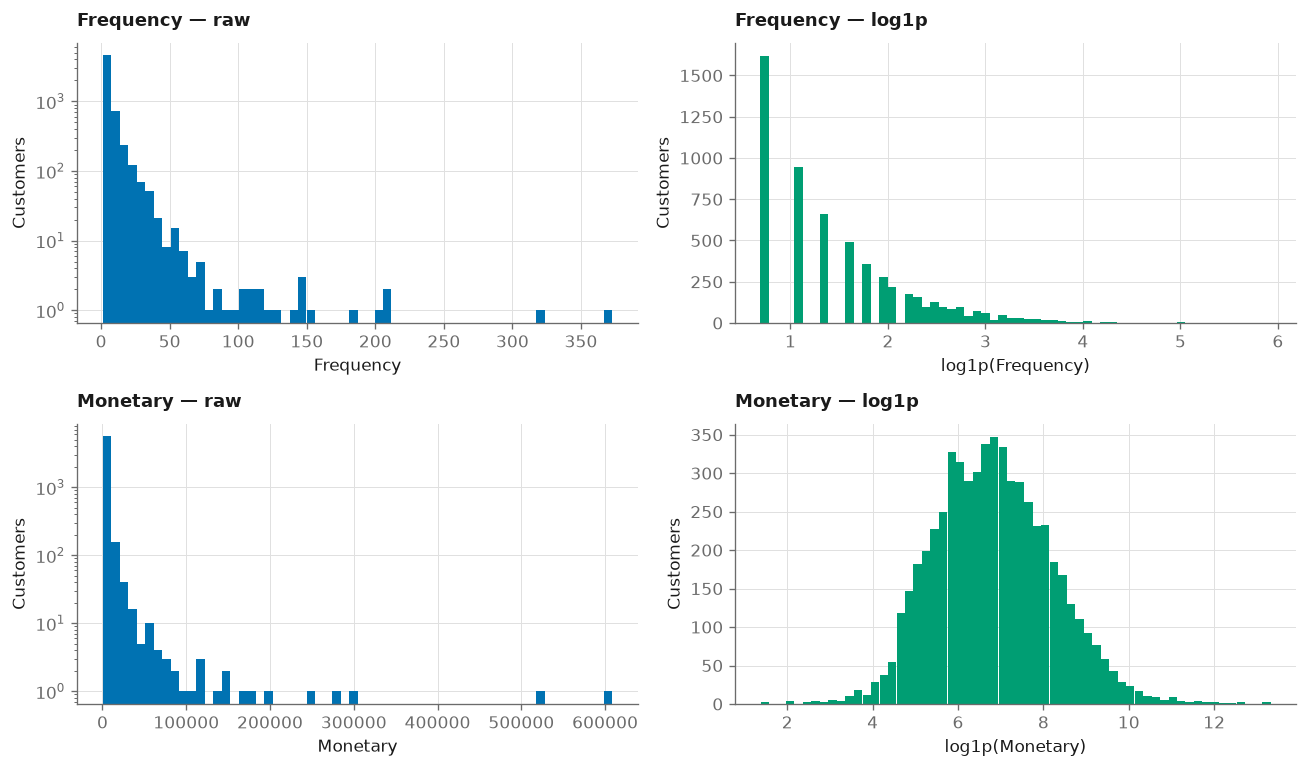

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for row, col in enumerate(["Frequency", "Monetary"]):
    axes[row, 0].hist(rfm[col], bins=60, color="#0072B2")
    finish(axes[row, 0], f"{col} — raw", col, "Customers")
    axes[row, 0].set_yscale("log")

    axes[row, 1].hist(np.log1p(rfm[col]), bins=60, color="#009E73")
    finish(axes[row, 1], f"{col} — log1p", f"log1p({col})", "Customers")

for col in ["Frequency", "Monetary"]:
    print(f"{col:10s} median {rfm[col].median():>10,.1f}   mean {rfm[col].mean():>10,.1f}"
          f"   max {rfm[col].max():>12,.1f}   skew {rfm[col].skew():>6.1f}")

plt.tight_layout(); plt.savefig(FIG_DIR / "rfm_skew_logtransform.png"); plt.show()

In [6]:
X = StandardScaler().fit_transform(np.log1p(rfm[CLUSTER_FEATURES]))
print("clustering matrix:", X.shape)

clustering matrix: (5852, 3)


## 4. Choosing K

Two diagnostics: inertia (the elbow) and silhouette. They disagree, and how you resolve
that is the interesting part.

**K=2 wins the raw silhouette outright** — and it's useless. It splits customers into
"bought recently" and "didn't", which is a fact the business already knows and can't act
on differently. A segmentation that returns *active vs inactive* has told you nothing.

So the choice is restricted to K≥3, where silhouette has a clear local maximum at **K=4**
that also sits in the elbow region. That gives four segments with genuinely different
marketing actions, which is the point of the exercise.

Silhouette is computed on a 5,000-customer sample for speed; the ranking is stable well
below full size.

In [7]:
rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(X), size=min(5000, len(X)), replace=False)

rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(X[sample_idx], km.labels_[sample_idx])})
scores = pd.DataFrame(rows)

nontrivial = scores[scores["k"] >= 3]
K = int(nontrivial.loc[nontrivial["silhouette"].idxmax(), "k"])
print(f"chosen K = {K}")
scores.round(4)

chosen K = 4


,k,inertia,silhouette
0,2,8561.3042,0.4367
1,3,6334.7452,0.3495
2,4,4905.4649,0.3670
3,5,4088.6984,0.3408
4,6,3547.9308,0.3301
5,7,3178.6311,0.3006
6,8,2887.6043,0.2949


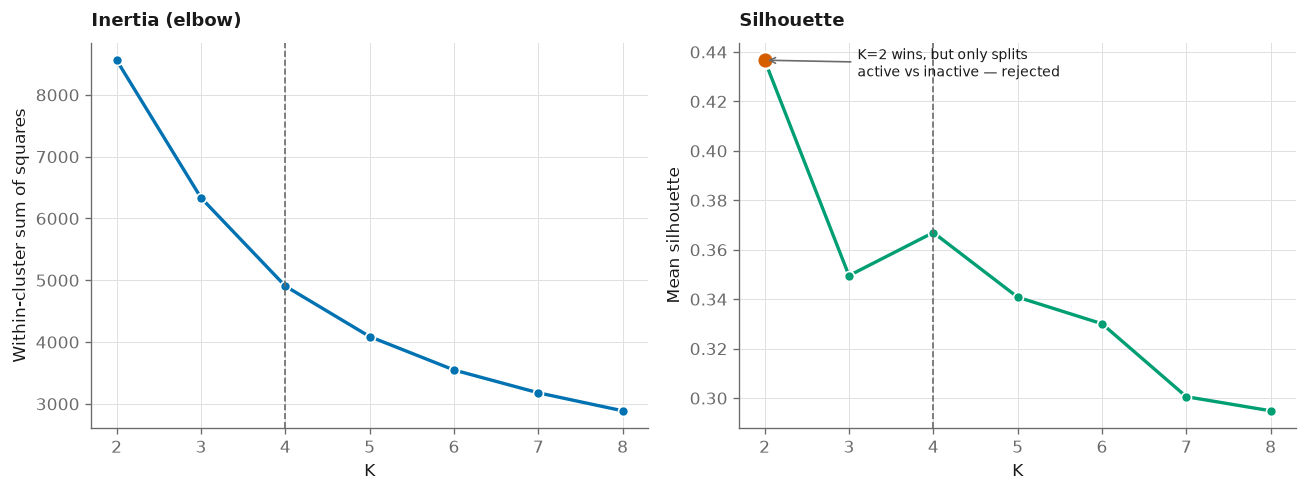

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(scores["k"], scores["inertia"], lw=2, marker="o", ms=6,
             color="#0072B2", markeredgecolor="white", markeredgewidth=1)
axes[0].axvline(K, ls="--", lw=1, color=MUTED)
finish(axes[0], "Inertia (elbow)", "K", "Within-cluster sum of squares")

axes[1].plot(scores["k"], scores["silhouette"], lw=2, marker="o", ms=6,
             color="#009E73", markeredgecolor="white", markeredgewidth=1)
axes[1].plot(2, scores.loc[scores.k == 2, "silhouette"].iloc[0], "o", ms=10,
             color="#D55E00", markeredgecolor="white", markeredgewidth=1.5)
axes[1].annotate("K=2 wins, but only splits\nactive vs inactive — rejected",
                 xy=(2, scores.loc[scores.k == 2, "silhouette"].iloc[0]),
                 xytext=(3.1, scores["silhouette"].max() * 0.985),
                 fontsize=8.5, color=INK,
                 arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
axes[1].axvline(K, ls="--", lw=1, color=MUTED)
finish(axes[1], "Silhouette", "K", "Mean silhouette")

plt.tight_layout(); plt.savefig(FIG_DIR / "k_selection.png"); plt.show()

## 5. Fit and name the segments

Cluster IDs mean nothing to a marketing team, so each one gets a name from its own
position relative to the population median — recent and frequent and high-spending is a
*Champion*; lapsed but formerly valuable is *At Risk*, which is the group worth a
win-back budget.

In [9]:
km = KMeans(n_clusters=K, n_init=25, random_state=SEED).fit(X)
rfm["Cluster"] = km.labels_

med = rfm[CLUSTER_FEATURES].median()
names = {}
for cid, grp in rfm.groupby("Cluster"):
    r, f, m = grp["Recency"].mean(), grp["Frequency"].mean(), grp["Monetary"].mean()
    recent, frequent, rich = r < med["Recency"], f > med["Frequency"], m > med["Monetary"]
    if recent and frequent and rich:
        names[cid] = "Champions"
    elif recent and frequent:
        names[cid] = "Loyal Customers"
    elif recent:
        names[cid] = "New Customers"
    elif rich:
        names[cid] = "At Risk"
    else:
        names[cid] = "Hibernating"

# Two clusters can land on the same rule at higher K; suffix by value so the
# names stay unique and ordered.
seen = {}
for cid in sorted(names, key=lambda c: rfm.loc[rfm.Cluster == c, "Monetary"].mean(),
                  reverse=True):
    seen[names[cid]] = seen.get(names[cid], 0) + 1
    if seen[names[cid]] > 1:
        names[cid] = f"{names[cid]} {seen[names[cid]]}"

rfm["Segment"] = rfm["Cluster"].map(names)
print(names)

{0: 'New Customers', 1: 'Hibernating', 2: 'Champions', 3: 'At Risk'}


## 6. Who are they?

In [10]:
total_rev = rfm["Monetary"].sum()
profile = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    AvgRecencyDays=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
    TotalRevenue=("Monetary", "sum"),
    AvgOrderValue=("AvgOrderValue", "mean"),
    AvgProductDiversity=("ProductDiversity", "mean"),
).round(1)
profile["RevenueShare"] = (profile["TotalRevenue"] / total_rev * 100).round(1)
profile["CustomerShare"] = (profile["Customers"] / len(rfm) * 100).round(1)
profile = profile.sort_values("TotalRevenue", ascending=False)
profile

,Customers,AvgRecencyDays,AvgFrequency,AvgMonetary,TotalRevenue,AvgOrderValue,AvgProductDiversity,RevenueShare,CustomerShare
Segment,,,,,,,,,
Champions,1114,25.4,19.8,11230.1,12510345.3,568.0,212.0,71.8,19.0
At Risk,1460,209.0,5.4,2177.3,3178906.1,494.8,87.0,18.2,24.9
New Customers,1237,28.4,3.0,837.2,1035559.6,316.3,56.3,5.9,21.1
Hibernating,2041,393.5,1.4,347.7,709653.7,265.3,23.6,4.1,34.9


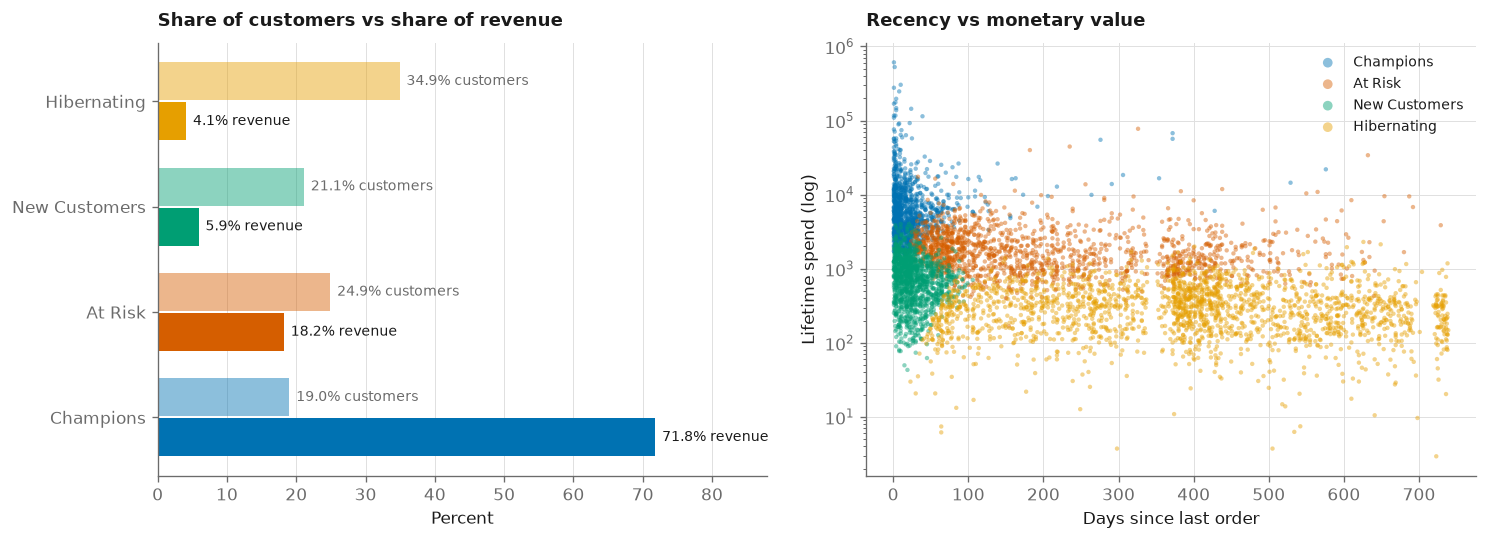

In [11]:
order = list(profile.index)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

# Customer share vs revenue share -- the whole argument for segmenting.
y = np.arange(len(order))
axes[0].barh(y + 0.19, profile["CustomerShare"], height=0.36,
             color=[SEGMENT_COLORS[s] for s in order], alpha=0.45)
axes[0].barh(y - 0.19, profile["RevenueShare"], height=0.36,
             color=[SEGMENT_COLORS[s] for s in order])
for i, s in enumerate(order):
    axes[0].text(profile.loc[s, "RevenueShare"] + 1, i - 0.19,
                 f"{profile.loc[s, 'RevenueShare']:.1f}% revenue", va="center", fontsize=8.5)
    axes[0].text(profile.loc[s, "CustomerShare"] + 1, i + 0.19,
                 f"{profile.loc[s, 'CustomerShare']:.1f}% customers", va="center",
                 fontsize=8.5, color=MUTED)
axes[0].set_yticks(y); axes[0].set_yticklabels(order)
axes[0].set_xlim(0, 88); axes[0].grid(axis="y", visible=False)
finish(axes[0], "Share of customers vs share of revenue", "Percent", "")

# Where the segments sit in the space K-Means actually used.
for s in order:
    g = rfm[rfm.Segment == s]
    axes[1].scatter(g["Recency"], g["Monetary"], s=7, alpha=0.45,
                    color=SEGMENT_COLORS[s], label=s, edgecolors="none")
axes[1].set_yscale("log")
finish(axes[1], "Recency vs monetary value", "Days since last order", "Lifetime spend (log)")
axes[1].legend(fontsize=8.5, markerscale=2.2, loc="upper right")

plt.tight_layout(); plt.savefig(FIG_DIR / "segments_scatter.png"); plt.show()

The left panel is the entire case for segmenting. Champions are a fifth of the customer
file and nearly three-quarters of the revenue; Hibernating are a third of the file and
4% of revenue. Spending the same acquisition-retention budget per head across those two
groups would be indefensible.

The right panel shows the clusters are mostly a recency story with a spend gradient
layered on it. The vertical band at the far right is real: those customers made their
last purchase over a year ago and haven't returned.

## 7. How solid are these clusters?

Silhouette per customer, plus how far each one sits from its own centroid versus the
nearest rival. That ratio — call it the boundary margin — is 0 for someone in the dead
centre of their segment and 0.5 for someone exactly on the fence between two.

This matters commercially, not just statistically: a customer on the boundary between
Champions and At Risk is the one where a retention campaign has the most to gain or lose.

In [12]:
segments = sorted(rfm["Segment"].unique())
centroids = np.vstack([X[rfm["Segment"].values == s].mean(axis=0) for s in segments])

dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
own_idx = np.array([segments.index(s) for s in rfm["Segment"]])
rows_ix = np.arange(len(rfm))

own = dists[rows_ix, own_idx]
masked = dists.copy(); masked[rows_ix, own_idx] = np.inf
rival_idx = masked.argmin(axis=1)
rival = masked[rows_ix, rival_idx]

rfm[["Z_Recency", "Z_Frequency", "Z_Monetary"]] = X
rfm["DistToCentroid"] = own.round(3)
rfm["DistToRival"] = rival.round(3)
rfm["NearestRival"] = [segments[i] for i in rival_idx]
rfm["BoundaryMargin"] = (own / (own + rival)).round(3)
rfm["Silhouette"] = silhouette_samples(X, own_idx).round(3)
rfm["Cohesion"] = np.select(
    [rfm["Silhouette"] >= 0.50, rfm["Silhouette"] >= BORDERLINE_SILHOUETTE],
    ["Core", "Settled"], default="Borderline")
rfm["IsBorderline"] = (rfm["Cohesion"] == "Borderline").astype(int)

borderline = rfm[rfm["Cohesion"] == "Borderline"]
print(f"borderline customers: {len(borderline):,} ({len(borderline)/len(rfm):.1%}), "
      f"lifetime value at stake ${borderline['Monetary'].sum():,.0f}")
print()
print(rfm.groupby("Segment")[["Silhouette", "BoundaryMargin"]].mean().round(3).to_string())

borderline customers: 1,735 (29.6%), lifetime value at stake $3,808,183

               Silhouette  BoundaryMargin
Segment                                  
At Risk             0.309           0.348
Champions           0.335           0.316
Hibernating         0.472           0.274
New Customers       0.290           0.347


Mean silhouette around 0.37 is modest, and worth saying plainly rather than dressing up:
these are not four crisply separated species of customer. RFM lives on a continuum, and
the clusters are convenient cut points along it rather than natural kinds. The value is
that the cut points are consistent, reproducible and tied to different actions — not that
nature drew the lines.

## 8. Export for the dashboard

Six tables for the Power BI report. Geography is deliberately not pre-aggregated — the
dashboard reads `Country` off the customer table so a segment slicer re-filters the map
the same way it re-filters everything else. A pre-rolled country table would keep showing
all-segment totals no matter what was selected.

In [13]:
export_cols = [
    "CustomerID", "Segment", "Country", "Recency", "Frequency", "Monetary",
    "AvgOrderValue", "InterPurchaseStd", "ProductDiversity", "TenureDays",
    "Z_Recency", "Z_Frequency", "Z_Monetary", "DistToCentroid", "DistToRival",
    "NearestRival", "BoundaryMargin", "Silhouette", "Cohesion", "IsBorderline",
]
customers = rfm[export_cols].round({
    "Recency": 0, "Frequency": 0, "Monetary": 2, "AvgOrderValue": 2,
    "InterPurchaseStd": 1, "ProductDiversity": 0, "TenureDays": 0,
    "Z_Recency": 3, "Z_Frequency": 3, "Z_Monetary": 3,
})

centroid_long = []
for s, c in zip(segments, centroids):
    grp = rfm[rfm["Segment"] == s]
    for order_i, (feature, z) in enumerate(zip(CLUSTER_FEATURES, c), start=1):
        centroid_long.append({
            "Segment": s, "Feature": feature,
            "FeatureOrder": order_i,          # keeps R-F-M reading order in Power BI
            "ZScore": round(float(z), 3),
            "ActualValue": round(float(grp[feature].mean()), 1),
            "Customers": int(len(grp)),
        })

k_table = scores.copy()
k_table["Chosen"] = np.where(k_table["k"] == K, "Chosen K", "Candidate")
k_table["Verdict"] = np.where(
    k_table["k"] == 2, "Trivial split (rejected)",
    np.where(k_table["k"] == K, "Selected", "Considered"))
k_table["silhouette"] = k_table["silhouette"].round(4)
k_table["inertia"] = k_table["inertia"].round(1)
k_table = k_table.rename(columns={"k": "K", "inertia": "Inertia",
                                  "silhouette": "Silhouette"})

outputs = {
    "cluster_customers.csv": customers,
    "cluster_centroids.csv": pd.DataFrame(centroid_long),
    "k_selection.csv": k_table,
    "dim_segment.csv": pd.DataFrame({"Segment": sorted(customers["Segment"].unique())}),
    "dim_country.csv": pd.DataFrame({"Country": sorted(customers["Country"].unique())}),
    "dim_cohesion.csv": pd.DataFrame({"Cohesion": ["Core", "Settled", "Borderline"]}),
}
for name, frame in outputs.items():
    frame.to_csv(BI_DIR / name, index=False, encoding="utf-8")
    print(f"{name:26} {len(frame):>6} rows x {len(frame.columns)} cols")

cluster_customers.csv        5852 rows x 20 cols
cluster_centroids.csv          12 rows x 6 cols
k_selection.csv                 7 rows x 5 cols
dim_segment.csv                 4 rows x 1 cols
dim_country.csv                41 rows x 1 cols
dim_cohesion.csv                3 rows x 1 cols


## 9. What to do with this

**Champions (19% of customers, 72% of revenue).** The whole business rests on roughly a
thousand accounts. The risk here isn't acquisition, it's silent churn — one of these
lapsing costs more than winning a dozen new customers. They warrant named account
handling and an alert the moment recency slips.

**At Risk (25%, 18%).** Lapsed but formerly valuable, averaging $2.2k lifetime spend and
209 days since their last order. This is where win-back budget belongs, and it decays
fast: the longer the gap, the lower the return.

**New Customers (21%, 6%).** Recent but shallow — three orders on average. The question
is whether they graduate toward Champions, and onboarding sequences are the lever.

**Hibernating (35%, 4%).** A third of the file producing 4% of revenue, averaging 394
days since last purchase. The honest recommendation is to stop spending on them beyond
the cheapest possible reactivation, and to accept most won't return.

## Limitations

The segmentation is a snapshot at one date. Customers move between segments continuously,
and nothing here tracks those transitions — that would need repeated snapshots.

Silhouette around 0.37 says the clusters overlap. They're useful cut points on a
continuum, not natural kinds, and roughly a fifth of customers sit close enough to a
boundary that a slightly different random seed or feature set would move them.

Two years of one UK retailer, ending 2011. The segment *structure* generalises; the
specific thresholds don't.

Finally, dropping anonymous transactions removes real revenue from the picture. The
segmentation describes identified customers only, which is the right scope for a model
meant to drive targeted marketing, but it isn't the whole business.